<a href="https://colab.research.google.com/github/Chiya18/Machine-deep-Learning-Projects/blob/main/AI_Fraud_Detection_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE


In [ ]:
# Load dataset
df = pd.read_csv("/content/creditcard.csv")

In [ ]:
# Features and target
X = df.drop('Class', axis=1)
y = df['Class']

In [ ]:
smote = SMOTE()

# Drop rows where y is NaN from both X and y
# This ensures both datasets are aligned and clean for SMOTE
valid_indices = y.dropna().index
X_cleaned = X.loc[valid_indices]
y_cleaned = y.loc[valid_indices]

X_resampled, y_resampled = smote.fit_resample(X_cleaned, y_cleaned)

In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)


In [ ]:
# Model
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)


RandomForestClassifier()

In [ ]:
# Prediction
y_pred = model.predict(X_test)

In [ ]:
# Evaluation
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[2358    1]
 [   0 2404]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2359
         1.0       1.00      1.00      1.00      2404

    accuracy                           1.00      4763
   macro avg       1.00      1.00      1.00      4763
weighted avg       1.00      1.00      1.00      4763



In [ ]:
import joblib

joblib.dump(model, "fraud_model.pkl")
print("Fraud Detection Model Saved!")

Fraud Detection Model Saved!


In [ ]:
loaded_model = joblib.load("fraud_model.pkl")

# Test prediction on first row
sample = X.iloc[0].values.reshape(1, -1)
print("Loaded Model Prediction:", loaded_model.predict(sample))

Loaded Model Prediction: [0.]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
print("\n--- Enter Transaction Details ---")

while True:
    try:
        time = float(input("Enter transaction time (e.g., 120.0): "))
        break
    except ValueError:
        print("Invalid input for time. Please enter a numerical value.")

while True:
    try:
        amount = float(input("Enter transaction amount (e.g., 50.0): "))
        break
    except ValueError:
        print("Invalid input for amount. Please enter a numerical value.")

# Create dummy input (same shape as dataset)
user_data = X.iloc[0].copy()

user_data['Time'] = time
user_data['Amount'] = amount

user_data = user_data.values.reshape(1, -1)

prediction = model.predict(user_data)

if prediction[0] == 1:
    print("Fraudulent Transaction")
else:
    print("Safe Transaction")


--- Enter Transaction Details ---
Enter transaction time (e.g., 120.0): 100
Enter transaction amount (e.g., 50.0): 1500
Safe Transaction ✅


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# Display fraudulent transactions from the original dataset
fraudulent_transactions = df[df['Class'] == 1]
print("Fraudulent Transactions in the original dataset:")
display(fraudulent_transactions.head())

Fraudulent Transactions in the original dataset:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
541,406,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.00,1.0
623,472,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00,1.0
4920,4462,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,...,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,239.93,1.0
6108,6986,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,...,0.573574,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,59.00,1.0
6329,7519,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,...,-0.379068,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,1.00,1.0


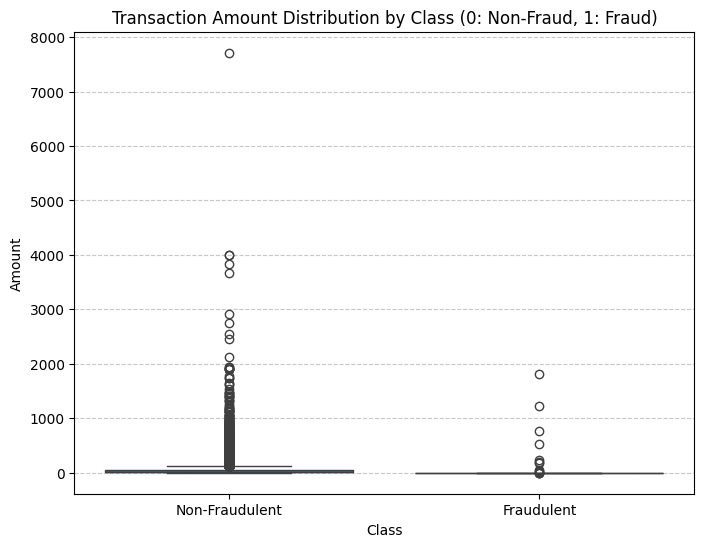

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a box plot to compare 'Amount' for fraudulent and non-fraudulent transactions
plt.figure(figsize=(8, 6))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title('Transaction Amount Distribution by Class (0: Non-Fraud, 1: Fraud)')
plt.xlabel('Class')
plt.ylabel('Amount')
plt.xticks(ticks=[0, 1], labels=['Non-Fraudulent', 'Fraudulent'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

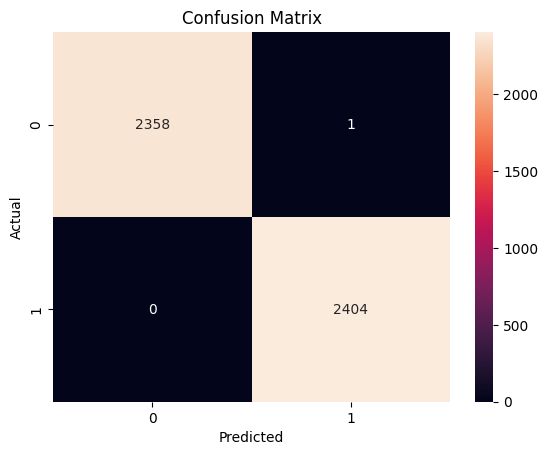

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("\nModel Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))


Model Performance:
Accuracy: 0.9997900482888935
Precision: 0.9995841995841996
Recall: 1.0
F1 Score: 0.9997920565606155
